In [ ]:
# CH2 케라스를 이용한 딥러닝 구현 

# ch2-1 케라스

# 1.1 케라스 모델 구현

# Sequential 클레스 이용
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense 

model = Sequential()
model.add(Dense(3, input_dim=4, activation="softmax"))

# 함수형 API 이용 
from tensorflow import keras 
from tensorflow.keras import layers 
a = keras.Input(shape=(32, ))
b = layers.Dense(32)(a)
model = keras.Model(inputs=a, outputs=b)

# 출력 모델 설정 (참조)
# model = keras.Model(inputs=[a1,a2], outputs=[b1,b2,b3])



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# chatGPT 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
model = Sequential()
model.add(Dense(50, activation='relu', input_shape=(11,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(6, activation='softmax'))
model.summary()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 50)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,316 (9.05 KB)

 Trainable params: 2,316 (9.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# chatGPT (Function AI)

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.layers import concatenate, Activation

# 1. 입력층 정의
inputs = Input(shape=(11,))

# 2. 병렬 은닉층 연결
x1 = Dense(50, activation='relu')(inputs)
x2 = Dense(30, activation='relu')(inputs)

# 3. 두 은닉층 출력 결합
x = Concatenate()([x1, x2])

# 4. 출력층 정의
outputs = Dense(3, activation='softmax')(x)

# 5. 모델 생성
model = Model(inputs=inputs, outputs=outputs)

# 모델 구조 확인
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 50)        │        600 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 30)        │        360 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 3)         │        243 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203 (4.70 KB)

 Trainable params: 1,203 (4.70 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# 1.2 MINIST 데이터 분류 모델

from tensorflow.keras.datasets import mnist 
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X, test_X = train_X / 255.0,  test_X / 255.0 

# Sequential()을 이용하여 모델 정의 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Flatten, Dense, Dropout

model  = Sequential()
model.add(Flatten(input_shape=(28,28))) 
model.add(Dense(360, activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(10, activation="softmax"))

# 손실함수 정의 모델평가방법 정의 
model.compile(loss="sparse_categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

# 훈련데이터 학습 
model.fit(train_X, train_y, batch_size=100, epochs= 10)
model.evaluate(test_X, test_y) 



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6919 - loss: 1.1042
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8549 - loss: 0.5021
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8828 - loss: 0.4069
Epoch 4/10
468/600 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8949 - loss: 0.3686

KeyboardInterrupt: 

In [6]:
# ch2-2 모델 저장하고 불러오기 

# 2.1  save()함수를 이용한 모델저장 

from tensorflow.keras.datasets import mnist 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X, test_X = train_X / 255.0,  test_X / 255.0 

model  = Sequential()
model.add(Flatten(input_shape=(28,28))) 
model.add(Dense(360, activation="relu"))
# model.add(Dropout(0.1))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(10, activation="softmax"))

# 손실함수 정의 모델평가방법 정의 
model.compile(loss="sparse_categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

# 훈련데이터 학습 
model.fit(train_X, train_y, batch_size=100, epochs= 10, verbose=1)       
model.evaluate(test_X, test_y) 

model.save("mnist_keras_model.h5")



Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7111 - loss: 1.0956
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.4841
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8866 - loss: 0.3907
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8999 - loss: 0.3437
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9090 - loss: 0.3144
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9175 - loss: 0.2896
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2710
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9269 - loss: 0.2534
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9319 - loss: 0.2394
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9348 - loss: 0.2263
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9441 - loss: 0.1909


In [2]:
#1. chatGPT MINIST 데이터 셋 불러오기 

import tensorflow as tf
from tensorflow.keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = \
    tf.keras.datasets.mnist.load_data()

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X, test_X = train_X / 255.0,  test_X / 255.0 

In [3]:
#2. chatGPT MINIST  딥러닝 모델 (Sequential())

# 3. Sequential 모델 정의
model = Sequential()

# 28x28 이미지를 784개 입력값으로 변환
model.add(Flatten(input_shape=(28, 28)))

# 은닉층 1
model.add(Dense(128, activation='relu'))

# 은닉층 2
model.add(Dense(64, activation='relu'))

# 출력층: 숫자 0~9, 총 10개 클래스
model.add(Dense(10, activation='softmax'))

# 4. 모델 구조 확인
model.summary()

NameError: name 'Sequential' is not defined

In [46]:
# 3. chatGPT MINIST  딥러닝 모델 컴파일 

model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [47]:
# 4. chatGPT MINIST  모델 학습, 평가

history = model.fit(
    train_X,
    train_y,
    epochs=10,
    batch_size=50,
    validation_split=0.2)


Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9168 - loss: 0.2866 - val_accuracy: 0.9564 - val_loss: 0.1441
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.1204 - val_accuracy: 0.9638 - val_loss: 0.1221
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9746 - loss: 0.0833 - val_accuracy: 0.9693 - val_loss: 0.1048
Epoch 4/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9814 - loss: 0.0610 - val_accuracy: 0.9698 - val_loss: 0.1040
Epoch 5/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9849 - loss: 0.0471 - val_accuracy: 0.9733 - val_loss: 0.1002
Epoch 6/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9877 - loss: 0.0380 - val_accuracy: 0.9743 - val_loss: 0.0931
Epoch 7/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9896 - loss: 0.0308 - val_accuracy: 0.9741 - val_loss: 0.0972
Epoch 8/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9919 - loss: 0.0248 - val_accuracy: 0.

In [48]:
# 4. chatGPT MINIST  모델 학습, 평가

model.fit(train_X, train_y, epochs=10, batch_size=50, validation_split=0.2)

loss, accuracy = model.evaluate(test_X, test_y)

print("Loss :", loss)
print("Accuracy :", accuracy)

Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9949 - loss: 0.0156 - val_accuracy: 0.9743 - val_loss: 0.1184
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.9753 - val_loss: 0.1244
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9753 - val_loss: 0.1197
Epoch 4/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9954 - loss: 0.0137 - val_accuracy: 0.9752 - val_loss: 0.1218
Epoch 5/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9967 - loss: 0.0101 - val_accuracy: 0.9714 - val_loss: 0.1415
Epoch 6/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9960 - loss: 0.0111 - val_accuracy: 0.9756 - val_loss: 0.1236
Epoch 7/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9958 - loss: 0.0122 - val_accuracy: 0.9750 - val_loss: 0.1300
Epoch 8/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9978 - loss: 0.0067 - val_accuracy: 0.

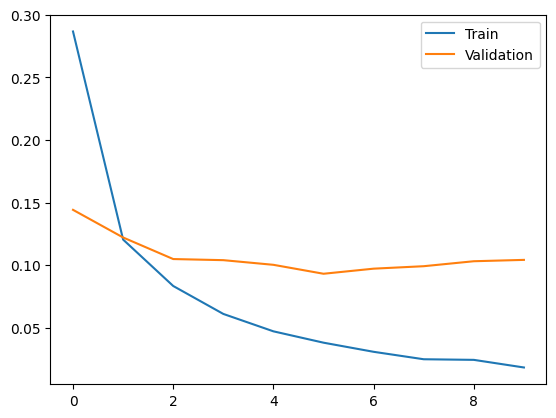

In [51]:
# 5. chatGPT MINIST  LOSS graph

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])
plt.show()

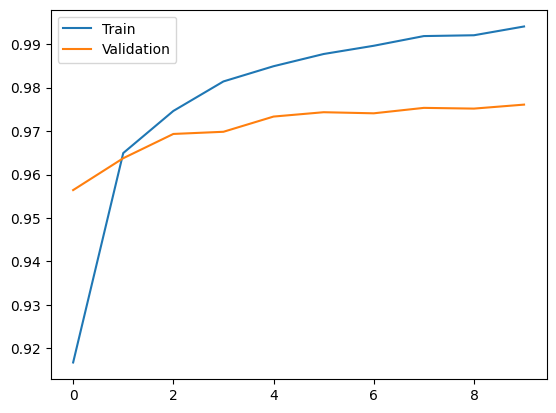

In [52]:
# 5. chatGPT MINIST Accuracy graph 

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.show()



In [2]:
# 6. chatGPT MINIST  전체코드 (모델 저장 및 불러오기)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Flatten, Dense

# 1. 데이터 불러오기
(train_X, train_y), (test_X, test_y) = tf.keras.datasets.mnist.load_data()

# 2. 정규화
train_X = train_X / 255.0
test_X = test_X / 255.0

# 3. 모델 생성
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 4. 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. 모델 학습
model.fit(
    train_X,
    train_y,
    epochs=10,
    batch_size=50,
    validation_split=0.2
)

# 6. 모델 평가
loss, accuracy = model.evaluate(test_X, test_y)
print("저장 전 Loss :", loss)
print("저장 전 Accuracy :", accuracy)

# 7. 모델 저장
model.save("mnist_model.keras")

# 8. 모델 불러오기
loaded_model = load_model("mnist_model.keras")

# 9. 불러온 모델 평가
loss, accuracy = loaded_model.evaluate(test_X, test_y)
print("불러온 모델 Loss :", loss)
print("불러온 모델 Accuracy :", accuracy)

# 10. 예측
pred = loaded_model.predict(test_X)
pred_class = pred.argmax(axis=1)

print("예측값 :", pred_class[0])
print("실제값 :", test_y[0])

Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9146 - loss: 0.2935 - val_accuracy: 0.9548 - val_loss: 0.1554
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9655 - loss: 0.1166 - val_accuracy: 0.9665 - val_loss: 0.1039
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9763 - loss: 0.0789 - val_accuracy: 0.9749 - val_loss: 0.0870
Epoch 4/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9813 - loss: 0.0593 - val_accuracy: 0.9744 - val_loss: 0.0883
Epoch 5/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9850 - loss: 0.0455 - val_accuracy: 0.9739 - val_loss: 0.0897
Epoch 6/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accuracy: 0.9717 - val_loss: 0.1037
Epoch 7/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9900 - loss: 0.0304 - val_accuracy: 0.9740 - val_loss: 0.0917
Epoch 8/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9927 - loss: 0.0222 - val_accuracy: 0.

In [3]:
# 교재 28page 코드 

from tensorflow.keras.datasets import mnist
(train_X, train_y), (test_X, test_y) = \
    tf.keras.datasets.mnist.load_data()

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X, test_X = train_X / 255.0,  test_X / 255.0 

import numpy as np
pred = np.argmax(model.predict(test_X), axis=1)
np.mean(np.equal(test_y, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step


np.float64(0.9743)

In [ ]:
# chatGPT (JSON 파일 모델 구조 저장하기)

model_json = model.to_json()

with open("model.json", "w") as json_file: json_file.write(model_json)

In [7]:
# chatGPT (JSON 파일 모델 구조 저장하기)
import json

# 모델 구조를 JSON 문자열로 변환
model_json = model.to_json()

# JSON 문자열을 파이썬 딕셔너리로 변환
model_json_dict = json.loads(model_json)

# 보기 좋게 들여쓰기하여 저장
with open("model_pretty.json", "w", encoding="utf-8") as f:
    json.dump(model_json_dict, f, indent=4, ensure_ascii=False)

In [ ]:
# 2.2 모델 구조 저장하기  (to_json()함수 이용 )

model_json = model.to_json()

with open("mnist_model.json", "w") as f:
    f.write(model_json)

# model_from_json()를 이용하여 데이터 불러오기 
with open("mnist_model.json", "r") as f:
    model_json=f.read()

from tensorflow.keras.models import model_from_json 
model = model_from_json(model_json)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [14]:
# load_weights() 가중치, compile() 실행,  evaluate() 평가 

model.load_weights("mnist_keras_model.h5")
model.compile(loss="sparse_categorical_crossentropy", optimizer="SGD", metrics= ["accuracy"])
model.evaluate(test_X, test_y)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8657 - loss: 0.5736


[0.5735989212989807, 0.8657000064849854]

In [4]:
# 2.3 모델의 구조와 가중치 불러오기 
# tf.keras.models.load_model() 함수는 save()함수로 저장된 모델을 불러옴. 

import tensorflow as tf

from tensorflow.keras.models import load_model 
model = load_model("mnist_keras_model.h5")

# 예측 및 평가 

from tensorflow.keras.datasets import mnist 
mnist = tf.keras.datasets.mnist

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X, test_X = train_X / 255.0,  test_X / 255.0 

import numpy as np

pred = np.argmax(model.predict(test_X), axis=1)
np.mean(np.equal(test_y, pred))



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


np.float64(0.8657)

In [10]:
# ch2-3 콜백을 이용한 딥러닝 모델관리 및 모니터링 

# 3.1 모델자동저장 콜백 _ ModelCheckPoint 
# tf.keras.callbacks.ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=False, save_weights_only=False, mode='auto', periode=1)

from tensorflow.keras.callbacks import ModelCheckpoint

path = "mnist-{epoch:02d}-{val_accuracy:.3f}.keras"
checkpoint = ModelCheckpoint(filepath=path, monitor="val_accuracy", save_best_only=True, verbose=1)

# model.fit(train_X, train_y, validation_split=0.2, batch_size=100, epochs=50, callbacks=[checkpoint], verbose=1)



In [ ]:
# chatGPT 전체코드 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. 모델 새로 생성
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(360, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 2. 반드시 새 optimizer로 다시 compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. 체크포인트 설정
path = "mnist-{epoch:02d}-{val_accuracy:.3f}.keras"

checkpoint = ModelCheckpoint(
    filepath=path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# 4. 모델 학습
history = model.fit(
    train_X,
    train_y,
    validation_split=0.2,
    batch_size=100,
    epochs=5,
    callbacks=[checkpoint],
    verbose=1)

Epoch 1/5
470/480 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8524 - loss: 0.5026
Epoch 1: val_accuracy improved from None to 0.95642, saving model to mnist-01-0.956.keras

Epoch 1: finished saving model to mnist-01-0.956.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9197 - loss: 0.2711 - val_accuracy: 0.9564 - val_loss: 0.1479
Epoch 2/5
466/480 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9681 - loss: 0.1061
Epoch 2: val_accuracy improved from 0.95642 to 0.96367, saving model to mnist-02-0.964.keras

Epoch 2: finished saving model to mnist-02-0.964.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9693 - loss: 0.1007 - val_accuracy: 0.9637 - val_loss: 0.1266
Epoch 3/5
465/480 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9806 - loss: 0.0635
Epoch 3: val_accuracy improved from 0.96367 to 0.97558, saving model to mnist-03-0.976.keras

Epoch 3: finished saving model to mnist-03-0.976.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss:

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy",metrics=["accuracy"])

model.fit(train_X, train_y, validation_split=0.2, batch_size=1000, epochs=10, callbacks=[checkpoint], verbose=1)

Epoch 1/10
44/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9991 - loss: 0.0024
Epoch 1: val_accuracy did not improve from 0.98167
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 0.9794 - val_loss: 0.1093
Epoch 2/10
43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9986 - loss: 0.0037
Epoch 2: val_accuracy did not improve from 0.98167
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 0.9793 - val_loss: 0.1064
Epoch 3/10
44/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9992 - loss: 0.0032
Epoch 3: val_accuracy did not improve from 0.98167
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9787 - val_loss: 0.1048
Epoch 4/10
43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9997 - loss: 0.0014
Epoch 4: val_accuracy did not improve from 0.98167
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9809 - val_loss: 0.098


Epoch 10: finished saving model to model-10- 0.9818.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 9.8907e-04 - val_accuracy: 0.9818 - val_loss: 0.1055


In [15]:
# 3.2 조기종료 콜백 (EarlyStopping) 
# tf.keras.callbacks.EarlyStopping (monitor='val_loss', min_data=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False) 
# fit()함수에 콜백을 설정

from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor="val_accuracy", patience=3)

model.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.fit(train_X, train_y, validation_data=(test_X, test_y), batch_size=50, epochs=10, callbacks=[early_stopping], verbose=1)

# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y)
print("저장 전 Loss :", loss)
print("저장 전 Accuracy :", accuracy)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9922 - loss: 0.0239 - val_accuracy: 0.9809 - val_loss: 0.0754
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9790 - val_loss: 0.0844
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9797 - val_loss: 0.0852
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9797 - val_loss: 0.0962
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9797 - loss: 0.0962
저장 전 Loss : 0.0962153747677803
저장 전 Accuracy : 0.9797000288963318


In [ ]:
# 3.3 학습시각화콜백_ Tensorboard 

# tf.keras.callbacks.TensorBoard(log_dir='logs', histogram_freq=0, write_graph=True, write_image=False, 
#                                update_freq='epoch', profile_batch=2, embeddings_freq=0, embeddings_metadata=None, **kwargs)


from tensorflow.keras.callbacks import TensorBoard 
tensor_board = TensorBoard(log_dir= "tensor_log", embeddings_freq=1, histogram_freq=1)

model.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.fit(train_X, train_y, validation_data=(test_X, test_y),batch_size=1000, epochs=10, callbacks=[tensor_board], verbose=1)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9984 - loss: 0.0046 - val_accuracy: 0.9821 - val_loss: 0.0866
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9989 - loss: 0.0035 - val_accuracy: 0.9828 - val_loss: 0.0833
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9833 - val_loss: 0.0792
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9834 - val_loss: 0.0844
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9842 - val_loss: 0.0829
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9845 - val_loss: 0.0795
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9848 - val_loss: 0.0832
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.9795 - v

In [14]:
from tensorflow.keras.callbacks import TensorBoard

tb = TensorBoard(log_dir="logs")

model.fit(
    train_X,
    train_y,
    epochs=10,
    validation_split=0.2,
    callbacks=[tb]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9848 - loss: 0.0470 - val_accuracy: 0.9868 - val_loss: 0.0383
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9875 - val_loss: 0.0407
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9936 - loss: 0.0187 - val_accuracy: 0.9893 - val_loss: 0.0339
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9839 - val_loss: 0.0543
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.9845 - val_loss: 0.0597
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0135 - val_accuracy: 0.9865 - val_loss: 0.0511
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9843 - val_loss: 0.0636
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9960 - loss: 0.0125 - 

In [ ]:
# chatGPT 코드 

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import TensorBoard
import os

# 1. 데이터 불러오기
(train_X, train_y), (test_X, test_y) = tf.keras.datasets.mnist.load_data()

# 정규화
train_X = train_X / 255.0
test_X = test_X / 255.0

# 모델 새로 생성
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(360, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 2. `텐서보드 로그 데이터를 저장할 디렉토리` 설정
# log_dir = os.path.join("logs", "fit")
log_dir = r"C:\Users\user\logs\fit"

# 3. TensorBoard 콜백 정의
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,   # 에포크마다 히스토그램 계산
    write_graph=True,   # 모델 그래프 시각화 기록
    write_images=True )  # 가중치 이미지 시각화 기록

# 4 모델 컴파일  
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# 5 모델 학습 시 콜백 전달
history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    batch_size=100,
    epochs=10,
    callbacks=[tensorboard_callback], verbose=1)

# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y)
print("저장 전 Loss :", loss)
print("저장 전 Accuracy :", accuracy)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9310 - loss: 0.2427 - val_accuracy: 0.9620 - val_loss: 0.1209
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9721 - loss: 0.0917 - val_accuracy: 0.9739 - val_loss: 0.0865
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9808 - loss: 0.0620 - val_accuracy: 0.9736 - val_loss: 0.0818
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9862 - loss: 0.0427 - val_accuracy: 0.9799 - val_loss: 0.0642
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9901 - loss: 0.0309 - val_accuracy: 0.9744 - val_loss: 0.0856
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9912 - loss: 0.0264 - val_accuracy: 0.9759 - val_loss: 0.0774
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9776 - val_loss: 0.0784
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.